# Métricas de enfoque sobre el video

### Ejercicio 1

Usando la métrica propuesta por el paper *Image Sharpness Measure for Blurred Images in Frequency Domain*, se toman regiones dentro de los distintos frames que componen el video de muestra `focus_video.mov` entregado por la cátedra para poder medir qué tan desenfocada está la imagen.

Se comienza por ilustrar la región de la imagen que será tomada para obtener las métricas:

1. Medición en el frame completo
2. Medición en una ventana centrada en la imagen del 10% de su área
3. Medición en una matriz de 7x7 cuadrados de 10 px de lado

La distinción en los distintos métodos permite enfocar distintas zonas de interés dentro de la imagen con la cual se puede hacer una idea general de la nitidez en un frame, en el caso de evaluar el frame completo; en una zona localizada que ya se tenga prevista, en el caso de la ventana; o un panorama general pero leyendo menos espacio en el caso de la matriz:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = "focus_video.mov"

def visualize_regions(video_path: str, window_area_factor: float = 0.1, matrix_window_block_size: int = 10, matrix_window_stride: int = 20):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    if not ret:
        print("No se pudo leer el primer frame.")
        cap.release()
        return

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Visualizar el ventana reducida
    minimized_h = int(h * window_area_factor)
    minimized_w = int(w * window_area_factor)
    
    # Coordenadas de la ventana centrada (medida desde la esquina superior izquierda)
    y1 = h // 2 - minimized_h // 2
    y2 = y1 + minimized_h
    x1 = w // 2 - minimized_w // 2
    x2 = x1 + minimized_w
    center_window = gray[y1:y2, x1:x2]

    # Imagen con recuadro centrado
    frame_box = frame.copy()
    cv2.rectangle(frame_box, (x1, y1), (x2, y2), (0, 128, 255), 2)  # Naranja

    # Visualizar matriz 7x7
    frame_grid = frame.copy()
    grid_rows, grid_cols = 7, 7

    grid_span = (grid_rows - 1) * matrix_window_stride + matrix_window_block_size  # 190 px
    y0 = h // 2 - grid_span // 2
    x0 = w // 2 - grid_span // 2

    for i in range(grid_rows):
        for j in range(grid_cols):
            yi = y0 + i * matrix_window_stride
            xi = x0 + j * matrix_window_stride
            if 0 <= yi < h - matrix_window_block_size and 0 <= xi < w - matrix_window_block_size:
                cv2.rectangle(frame_grid,
                              (xi, yi),
                              (xi + matrix_window_block_size, yi + matrix_window_block_size),
                              (0, 255, 0), 1)  # Verde

    # ------------------------
    # Mostrar ambas imágenes
    # ------------------------
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(frame_box, cv2.COLOR_BGR2RGB))
    plt.title("Área central 10% (naranja)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(frame_grid, cv2.COLOR_BGR2RGB))
    plt.title("Matriz 7x7 de bloques 10x10 (verde)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    cap.release()

visualize_regions(video_path, window_area_factor=0.1, matrix_window_block_size=20, matrix_window_stride=40)

Habiendo visualizado las regiones de control, se aplica la medición de nitidez tomada del documento mencionado:

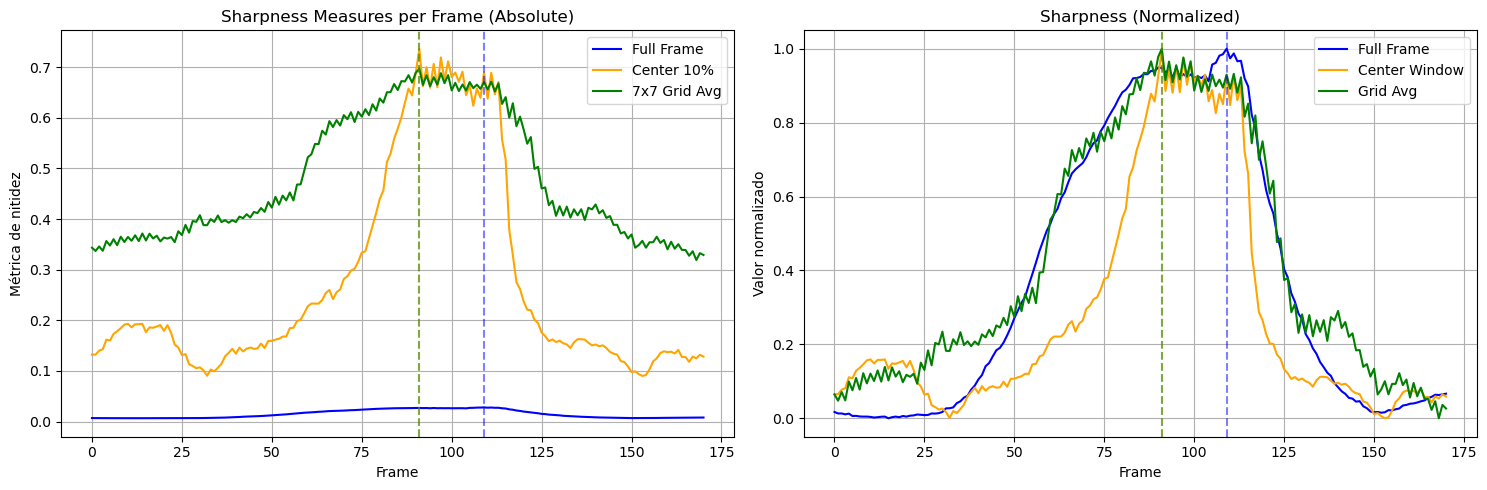

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Métrica de nitidez
def sharpness_FM(gray_img: np.ndarray) -> float:
    """
    Aplica la métrica del paper: Frequency-domain sharpness.
    Parámetro:
        gray_img: imagen 2D en escala de grises
    Retorno:
        FM: métrica de nitidez
    """
    # Aplicar transformada de Fourier. Importante usar shift para centrado del espectro
    F = np.fft.fft2(gray_img)
    Fc = np.fft.fftshift(F)
    
    # Módulo del espectro y cálculo del umbral
    AF = np.abs(Fc)
    M = AF.max()
    threshold = M / 1000
    TH = np.sum(AF > threshold)
    
    # La métrica esta dada por el número de componentes de alta frecuencia
    # que superan el umbral, normalizado por el número total de píxeles
    FM = TH / (gray_img.shape[0] * gray_img.shape[1])
    return FM

# División del video en frames y aplicación de la métrica de nitidez
def analyze_video(video_path: str, sharpness_fn, window_area_factor: float = 0.1, matrix_window_block_size: int = 10, matrix_window_stride: int = 20) -> tuple:
    cap = cv2.VideoCapture(video_path)
    fm_full_list = []
    fm_center_list = []
    fm_grid_avg_list = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convertir a escala de grises
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Nitidez en el frame completo
        fm_full = sharpness_fn(gray)

        # Tamaño de la ventana reducida
        h, w = gray.shape
        minimized_h = int(h * window_area_factor)
        minimized_w = int(w * window_area_factor)
        
        # Coordenadas de la ventana centrada (medida desde la esquina superior izquierda)
        y1 = h // 2 - minimized_h // 2
        y2 = y1 + minimized_h
        x1 = w // 2 - minimized_w // 2
        x2 = x1 + minimized_w
        center_window = gray[y1:y2, x1:x2]
        fm_center = sharpness_fn(center_window)

        # Matriz de 7x7 máscaras
        grid_fm_values = []
        grid_rows, grid_cols = 7, 7

        # Centrar matriz en la imagen
        grid_span = (grid_rows - 1) * matrix_window_stride + matrix_window_block_size
        y0 = h // 2 - grid_span // 2
        x0 = w // 2 - grid_span // 2

        for i in range(grid_rows):
            for j in range(grid_cols):
                yi = y0 + i * matrix_window_stride
                xi = x0 + j * matrix_window_stride
                if yi + matrix_window_block_size <= h and xi + matrix_window_block_size <= w and yi >= 0 and xi >= 0:
                    block = gray[yi:yi+matrix_window_block_size, xi:xi+matrix_window_block_size]
                    grid_fm_values.append(sharpness_fn(block))

        fm_grid_avg = np.mean(grid_fm_values) if grid_fm_values else 0

        fm_full_list.append(fm_full)
        fm_center_list.append(fm_center)
        fm_grid_avg_list.append(fm_grid_avg)

    cap.release()
    return fm_full_list, fm_center_list, fm_grid_avg_list

def normalize_series(series):
    arr = np.array(series)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)  # +1e-8 para evitar división por 0

# Graficar las métricas de nitidez
def plot_sharpness(fm_full_list, fm_center_list, fm_grid_avg_list):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    frames = list(range(len(fm_full_list)))

    # Graficar curvas
    axs[0].plot(frames, fm_full_list, color='blue', label='Full Frame')
    axs[0].plot(frames, fm_center_list, color='orange', label='Center 10%')
    axs[0].plot(frames, fm_grid_avg_list, color='green', label='7x7 Grid Avg')

    # Detectar y marcar máximos
    max_full = np.argmax(fm_full_list)
    max_center = np.argmax(fm_center_list)
    max_grid = np.argmax(fm_grid_avg_list)

    axs[0].axvline(max_full, color='blue', linestyle='--', alpha=0.5)
    axs[0].axvline(max_center, color='orange', linestyle='--', alpha=0.5)
    axs[0].axvline(max_grid, color='green', linestyle='--', alpha=0.5)

    # Plot settings
    axs[0].set_xlabel("Frame")
    axs[0].set_ylabel("Métrica de nitidez")
    axs[0].set_title('Sharpness Measures per Frame (Absolute)')
    axs[0].legend()
    axs[0].grid(True)

    # Versión normalizada
    norm_full = normalize_series(fm_full)
    norm_center = normalize_series(fm_center)
    norm_grid = normalize_series(fm_grid)

    axs[1].plot(frames, norm_full, label="Full Frame", color="blue")
    axs[1].plot(frames, norm_center, label="Center Window", color="orange")
    axs[1].plot(frames, norm_grid, label="Grid Avg", color="green")
    axs[1].axvline(max_full, color='blue', linestyle='--', alpha=0.5)
    axs[1].axvline(max_center, color='orange', linestyle='--', alpha=0.5)
    axs[1].axvline(max_grid, color='green', linestyle='--', alpha=0.5)
    axs[1].set_title("Sharpness (Normalized)")
    axs[1].set_xlabel("Frame")
    axs[1].set_ylabel("Valor normalizado")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_FM,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)


Se observa como resultado dos gráficas:

* La primera gráfica muestra el valor absoluto de la métrica, que nos pemite medir la dispersión general de la nitidez en la región evaluada por cada uno de los frames. Hay una gran variación entre las regiones evaluadas, de modo que el comportamiento de las medidas más centradas se vuelve más agudo sobre la mitad del video (como nos indica la curva de la ventana al 10%) pero en promedio no existe una variación muy grande en la nitidez de la imagen (como se puede deducir de las otras dos gráficas). 

* La segunda gráfica muestra el valor normalizado de acuerdo a cada región. Esta gráfica es útil para analizar los freames en los que se observa más desenfoque o más nitidez en la imagen independientemente de la región en la que se evalúa, pudiendo observar un patrón similar en todas las mediciones e indicando que sobre el segmento intermedio del video se enfoca más la imagen.

En resumen: la primer gráfica muestra que si bien la nitidez varía a lo largo del tiempo en el video, no hay zonas dentro de un mismo frame que estén más enfocadas que otras. La segunda gráfica indica que el enfoque de los frames varía, temporalmente hablando, entorno al mismo tiempo.

En un caso aplicado, la medición matricial serviría cuando se busca un enfoque generalizado en el frame de la imagen (por ejemplo para capturar paisajes); mientras que la ventana centrada es más útil en aplicaciones donde se busca mostrar un objeto en detalle incluso a costa de un desenfoque en el resto de la imagen (por ejemplo para capturar un retrato).

# Ejercicio 2

De manera complementaria se analizan otras métricas propuestas por el paper *Analysis of focus measure operators in shapeform focus*. La función de métrica es parametrizable en la función de procesamiento del video, de modo que se pueden crear nuevas funciones que funcionan como *plug-ins* fácilmente en los métodos ya evaluados.

A continuación se muestran gráficas para cada método desarrollado en el documento técnico proporcionado:

### LAPV

$$
FM_{LAPV} = Var(∇^2*I)
$$

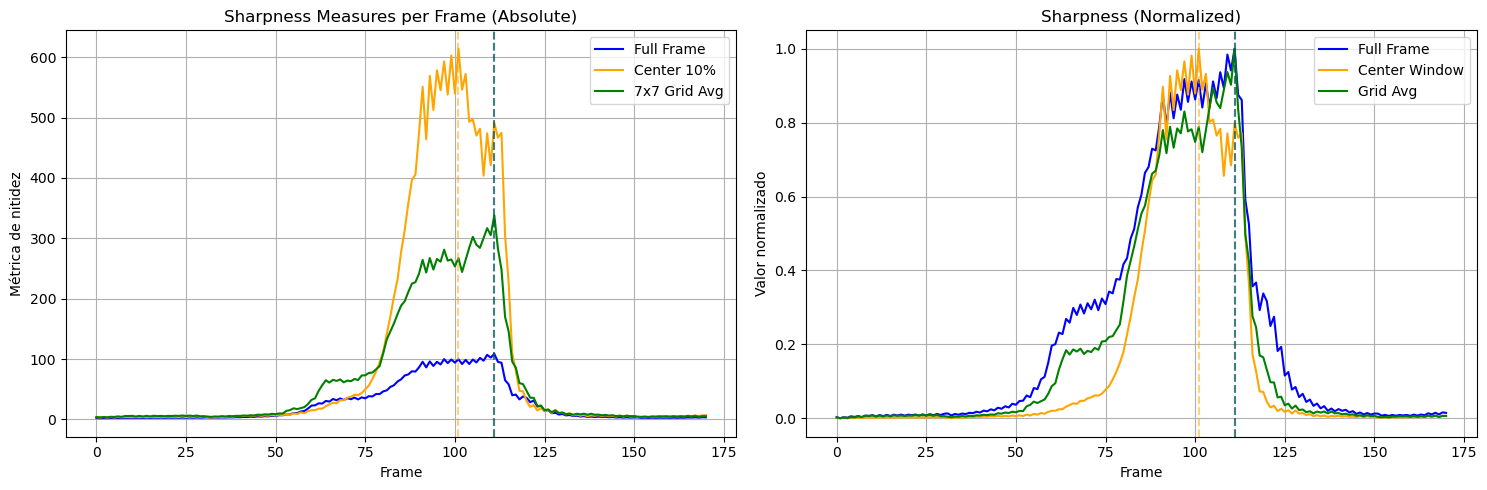

In [27]:
def sharpness_lapv(gray_img: np.ndarray) -> float:
    lap = cv2.Laplacian(gray_img, cv2.CV_64F)
    return np.var(lap)

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_lapv,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)

Con esta métrica se observa una medición más permisiva con el ruido en la nitidez, de modo que no afectan en su medición pequeños cambios en el enfoque real del frame sino que pondera más los momentos donde verdaderamente se hace foco, similar al comportamiento del ojo humano.

### LAPE

$$
FM_{LAPE} = \sum_{x,y} (∇^2 * I(x,y))^2
$$

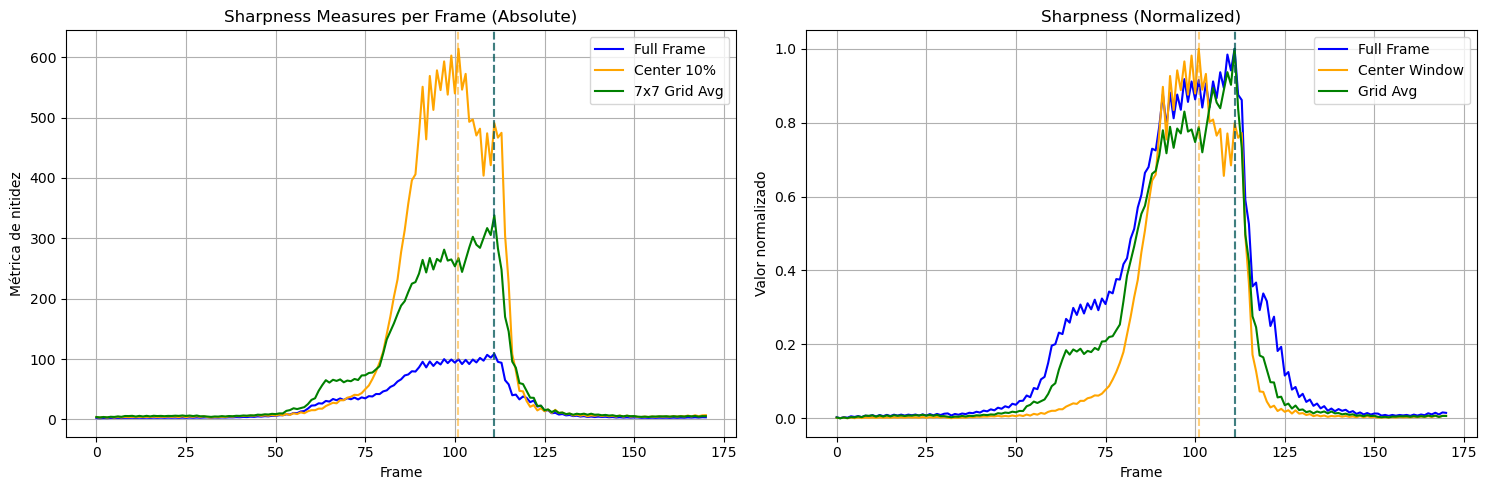

In [28]:
def sharpness_lape(gray_img: np.ndarray) -> float:
    lap = cv2.Laplacian(gray_img, cv2.CV_64F)
    energy = np.sum(lap**2)
    return energy / (gray_img.shape[0] * gray_img.shape[1])

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_lape,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)

Se observan conclusiones similares al caso anterior, pero esta vez la métrica es evaluada píxel a píxel, de modo que si en la imagen hubieran zonas que se vieran con más nitidez que otras seguramente se vería reflejado en los valores de las gráficas.

### LAPM

$$
FM_{LAPM} = \sum_{x,y} ∣I(x+1,y)−2I(x,y)+I(x−1,y)∣+∣I(x,y+1)−2I(x,y)+I(x,y−1)∣
$$

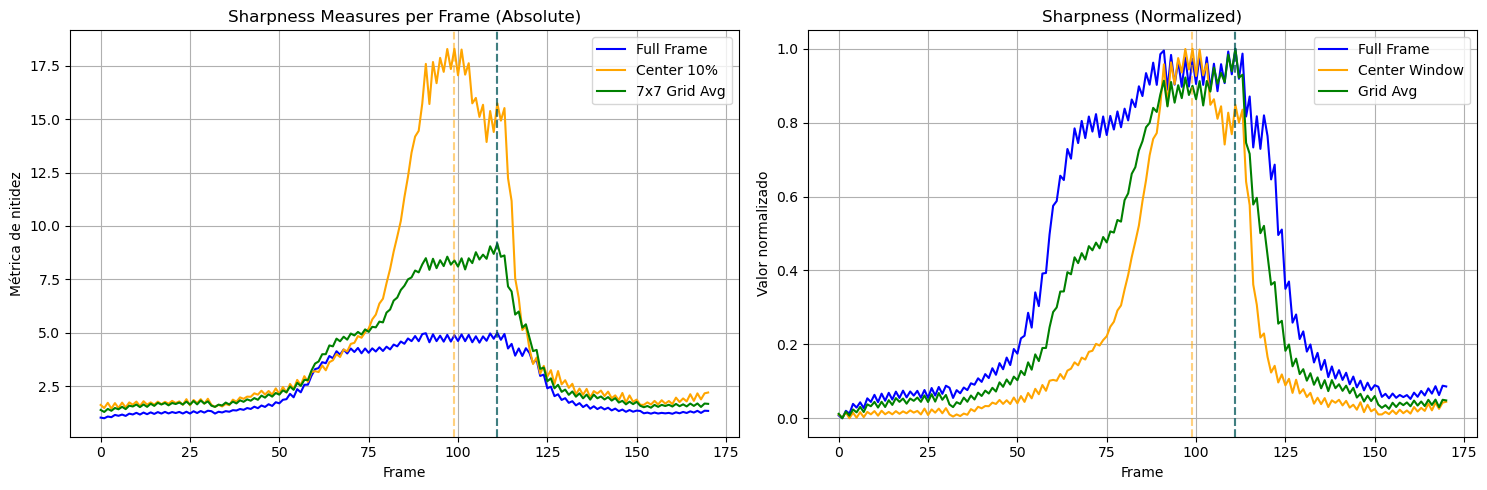

In [29]:
def sharpness_lapm(gray_img: np.ndarray) -> float:
    kernel_x = np.array([[0, -1, 0],
                         [0,  2, 0],
                         [0, -1, 0]])
    
    kernel_y = np.array([[0,  0, 0],
                         [-1, 2, -1],
                         [0,  0, 0]])

    fm_x = cv2.filter2D(gray_img, cv2.CV_64F, kernel_x)
    fm_y = cv2.filter2D(gray_img, cv2.CV_64F, kernel_y)
    return np.mean(np.abs(fm_x)) + np.mean(np.abs(fm_y))

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_lapm,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)

Se observan conclusiones similares a los casos anteriores, pero esta vez la magnitud de las mediciones es más tenue y pondera diferencias en un barrido vertical y uno horizontal de la imagen.

### LAPD

$$
FM_{LAPD} = \sum_{x,y} ∣Δ_x I(x,y)∣+∣Δ_y I(x,y)∣
$$

Donde:

$$
Δ_𝑥 I(x,y)=I(x+1,y)−2I(x,y)+I(x−1,y),
$$
$$
Δ_y I(x,y)=I(x,y+1)−2I(x,y)+I(x,y−1)
$$

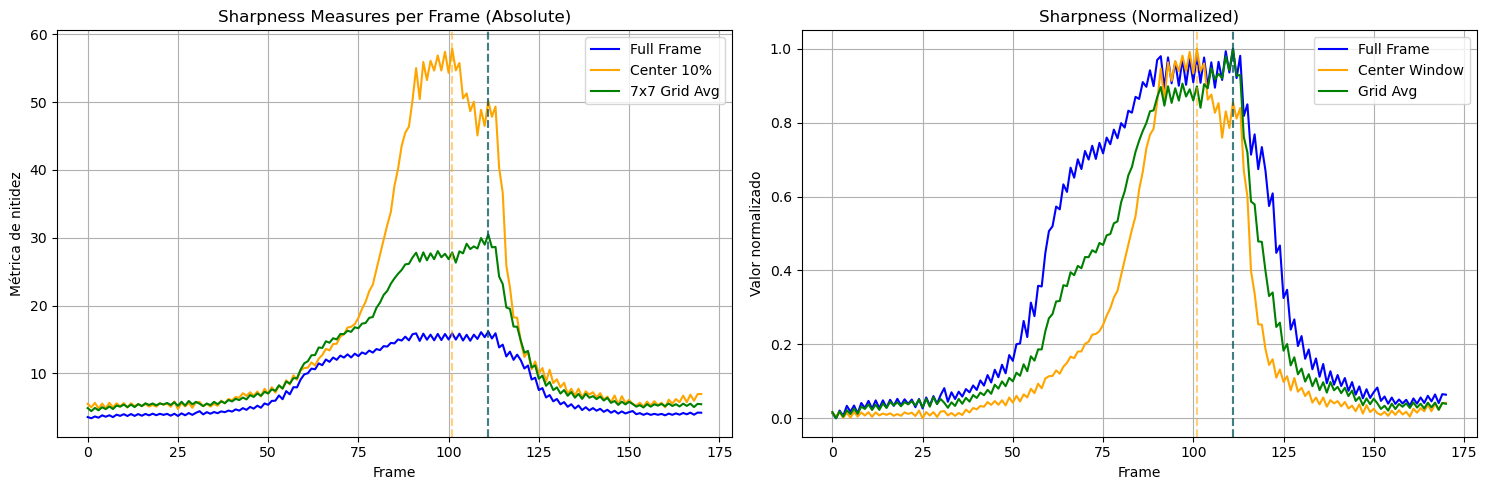

In [30]:
def sharpness_lapd(gray_img: np.ndarray) -> float:
    dx = cv2.Sobel(gray_img, cv2.CV_64F, 2, 0, ksize=3)
    dy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 2, ksize=3)
    return np.mean(np.abs(dx)) + np.mean(np.abs(dy))

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_lapd,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)

Se observan conclusiones similares a los casos anteriores, pero tiene más en cuenta variaciones producidas en ejes horizontales y verticales en bordes detectados dentro de la imagen.

### TENG

$$
FM_{TENG} = \frac{1}{MN} \sum_{x,y} \sqrt{G_x(x,y)^2 + G_x(x,y)^2}​
$$

Donde $G_x$ y $G_y$ son los gradientes de Sobel

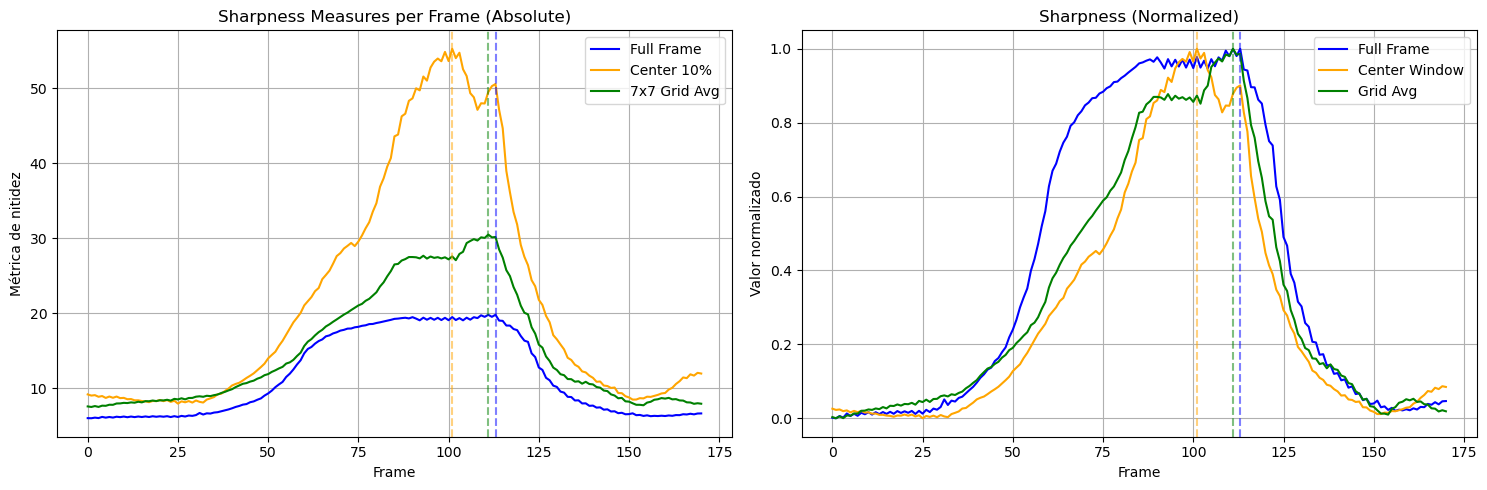

In [31]:
def sharpness_tenengrad(gray_img: np.ndarray) -> float:
    """
    Sharpness basada en el método Tenengrad.
    Usa los gradientes de Sobel en X e Y.
    """
    gx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.mean(magnitude)

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_tenengrad,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)

Esta gráfica presenta una forma más suavizada de representar los valores, de acuerdo, una vez más, a cómo percibe el proceso de enfoque una persona.

### Sobel

$$
FM_{SOBEL} = \sum_{x,y} ∣G_x (x,y)∣+∣G_y (x,y)∣
$$

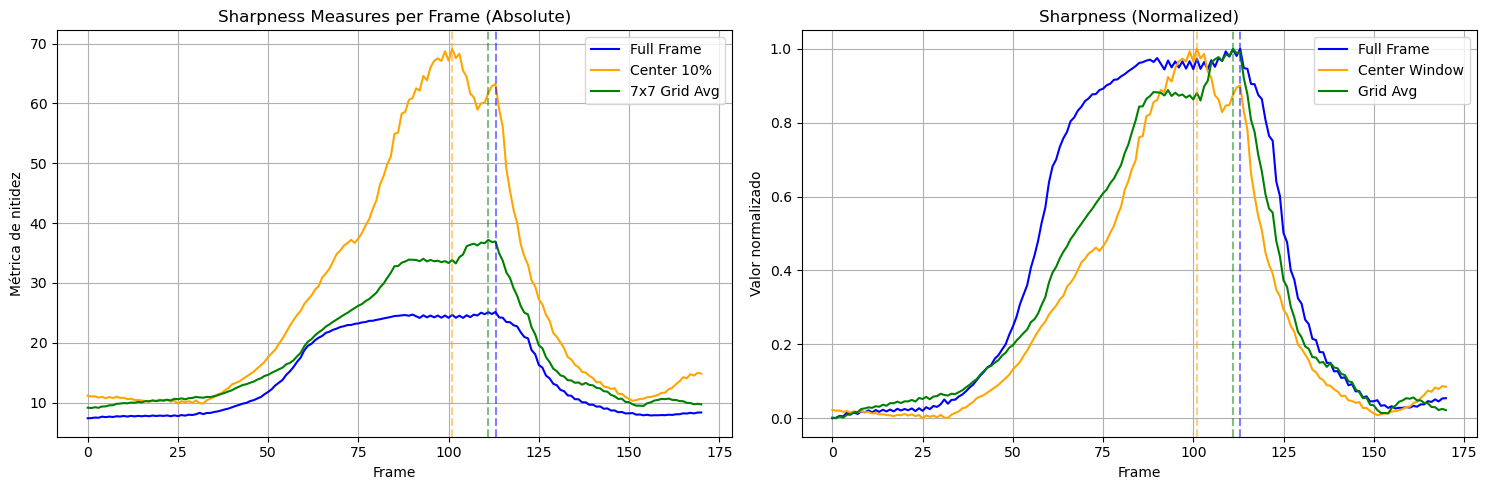

In [32]:
def sharpness_sobel(gray_img: np.ndarray) -> float:
    gx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    return np.mean(np.abs(gx)) + np.mean(np.abs(gy))

fm_full, fm_center, fm_grid = analyze_video(
    video_path=video_path,
    sharpness_fn=sharpness_sobel,
    window_area_factor=0.1,
    matrix_window_block_size=20,
    matrix_window_stride=40
)
plot_sharpness(fm_full, fm_center, fm_grid)

# Ejercicio complementario

Por último, como complemento de lo evaluado hasta ahora, se aplica el algoritmo de *unsharp masking* sobre la imagen pero solo cuando vale la pena computarlo: no tiene sentido mejorar una imagen con una métrica de nitidez muy pobre; pero tampoco conviene aplicarla si ya está lo suficientemente bien enfocada. Por ello, se aplica el mismo análisis con `sharpness_FM` sobre el video y se aplica el algoritmo `apply_unsharp_mask` cuando el valor de la métrica está entre el 70 y el 90% del valor de nitidez relativo precalculado:

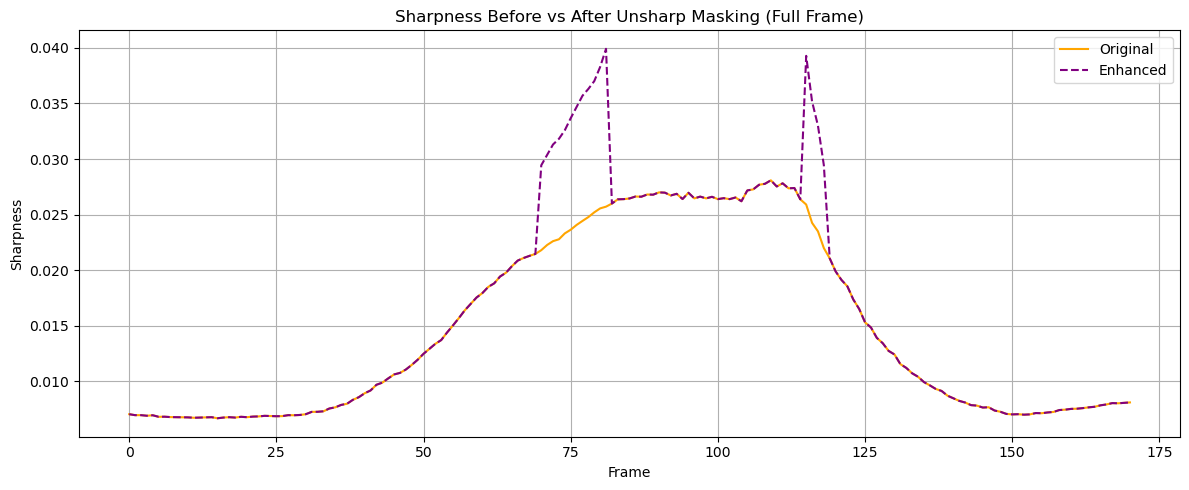

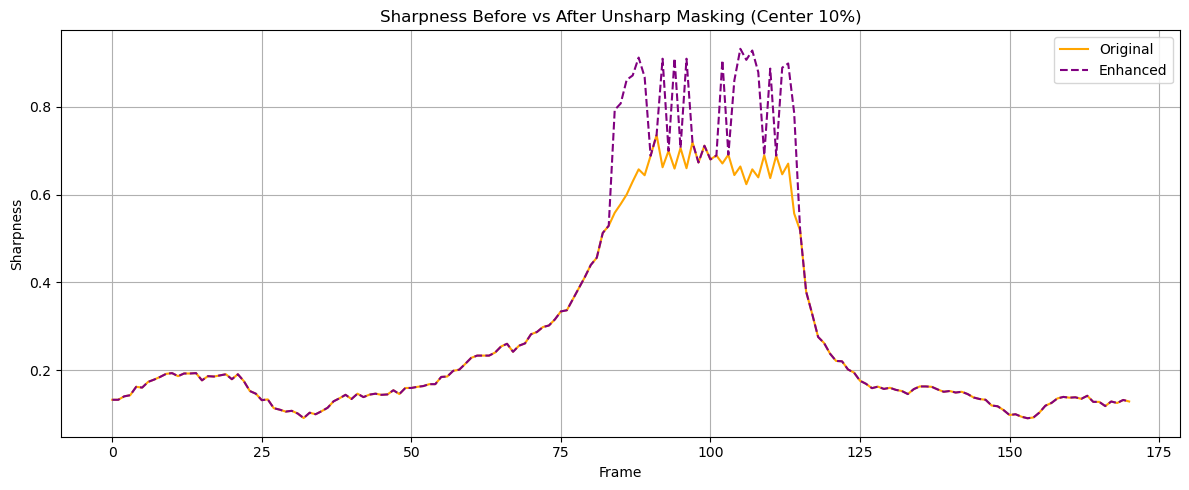

In [ ]:
def apply_unsharp_mask(image: np.ndarray, alpha: float = 1.5, kernel_size: int = 5) -> np.ndarray:
    """
    Aplica unsharp masking a una imagen en escala de grises.
    """
    blurred = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    mask = cv2.addWeighted(image, 1 + alpha, blurred, -alpha, 0)
    return mask

def enhance_and_compare(
    original_frames: list,
    sharpness_fn,
    region_selector: str = "center",  # 'full', 'center', 'grid'
    sharpness_values: list = None,
    threshold_low: float = 0.7,
    threshold_high: float = 0.9,
    window_area_factor: float = 0.1,
    matrix_window_block_size: int = 10,
    matrix_window_stride: int = 20
):
    """
    Aplica unsharp masking a los frames donde la nitidez normalizada esté en el rango [threshold_low, threshold_high],
    y compara la nitidez antes y después para la región seleccionada.
    """

    assert region_selector in {"full", "center", "grid"}

    norm_values = normalize_series(sharpness_values)

    enhanced_values = []

    for idx, frame in enumerate(original_frames):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        h, w = gray.shape

        if not (threshold_low <= norm_values[idx] <= threshold_high):
            enhanced_values.append(sharpness_values[idx])
            continue  # No aplicar mejora

        # --- Seleccionar región ---
        if region_selector == "full":
            region = gray

        elif region_selector == "center":
            minimized_h = int(h * window_area_factor)
            minimized_w = int(w * window_area_factor)
            y1 = h // 2 - minimized_h // 2
            y2 = y1 + minimized_h
            x1 = w // 2 - minimized_w // 2
            x2 = x1 + minimized_w
            region = gray[y1:y2, x1:x2]

        elif region_selector == "grid":
            grid_rows, grid_cols = 7, 7
            grid_span = (grid_rows - 1) * matrix_window_stride + matrix_window_block_size
            y0 = h // 2 - grid_span // 2
            x0 = w // 2 - grid_span // 2

            sharp_values = []
            for i in range(grid_rows):
                for j in range(grid_cols):
                    yi = y0 + i * matrix_window_stride
                    xi = x0 + j * matrix_window_stride
                    if 0 <= yi <= h - matrix_window_block_size and 0 <= xi <= w - matrix_window_block_size:
                        block = gray[yi:yi+matrix_window_block_size, xi:xi+matrix_window_block_size]
                        block_sharp = sharpness_fn(apply_unsharp_mask(block))
                        sharp_values.append(block_sharp)
            enhanced_values.append(np.mean(sharp_values))
            continue

        # --- Aplicar unsharp masking y recalcular nitidez ---
        enhanced = apply_unsharp_mask(region)
        enhanced_score = sharpness_fn(enhanced)
        enhanced_values.append(enhanced_score)

    return enhanced_values

def plot_comparison(original_values, enhanced_values, region_label):
    frames = range(len(original_values))

    plt.figure(figsize=(12, 5))
    plt.plot(frames, original_values, label="Original", color="orange")
    plt.plot(frames, enhanced_values, label="Enhanced", color="purple", linestyle='--')
    plt.title(f"Sharpness Before vs After Unsharp Masking ({region_label})")
    plt.xlabel("Frame")
    plt.ylabel("Sharpness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Cargar video y guardar frames
cap = cv2.VideoCapture(video_path)
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
cap.release()

# Analizar nitidez original
fm_full, fm_center, fm_grid = analyze_video(video_path, sharpness_fn=sharpness_FM)

# Aplicar mejora en el frame entero
enhanced_full = enhance_and_compare(
    original_frames=frames,
    sharpness_fn=sharpness_FM,
    region_selector="full",
    sharpness_values=fm_full
)
plot_comparison(fm_full, enhanced_full, region_label="Full Frame")

# Aplicar mejora en la región central
enhanced_center = enhance_and_compare(
    original_frames=frames,
    sharpness_fn=sharpness_FM,
    region_selector="center",
    sharpness_values=fm_center
)
plot_comparison(fm_center, enhanced_center, region_label="Center 10%")

Se observan algunos picos de intensidad en los que aumenta muy significativamente la nitidez del video, indicando así que el algoritmo es efectivo. Para normalizar la forma que adquiere la nitidez en los frames se aplica a modo experimental sin límite superior, de modo que se suavice la aplicación sobre las imágenes a partir de cierto umbral y no existan artefactos como resultado de estod cambios bruscos:

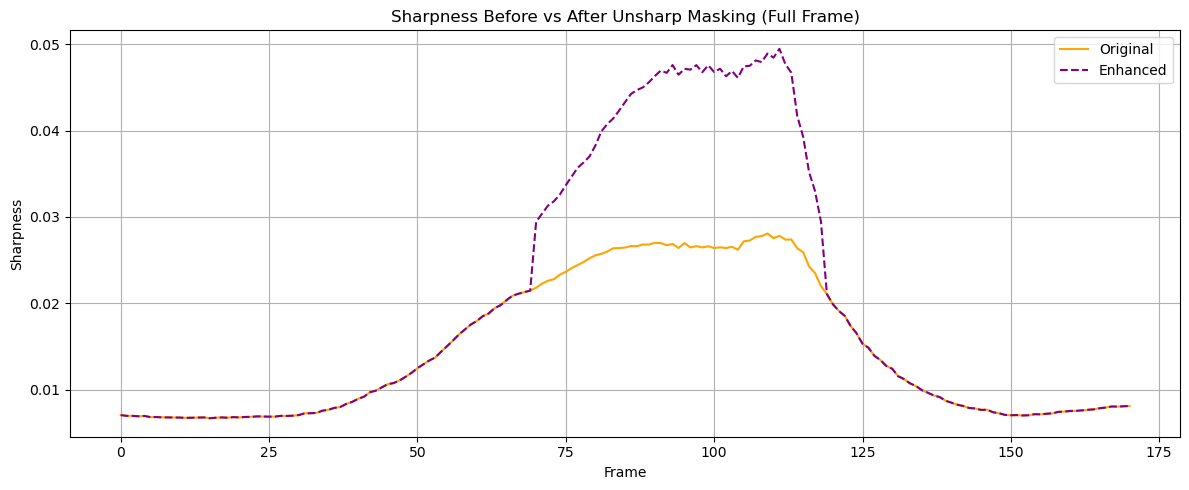

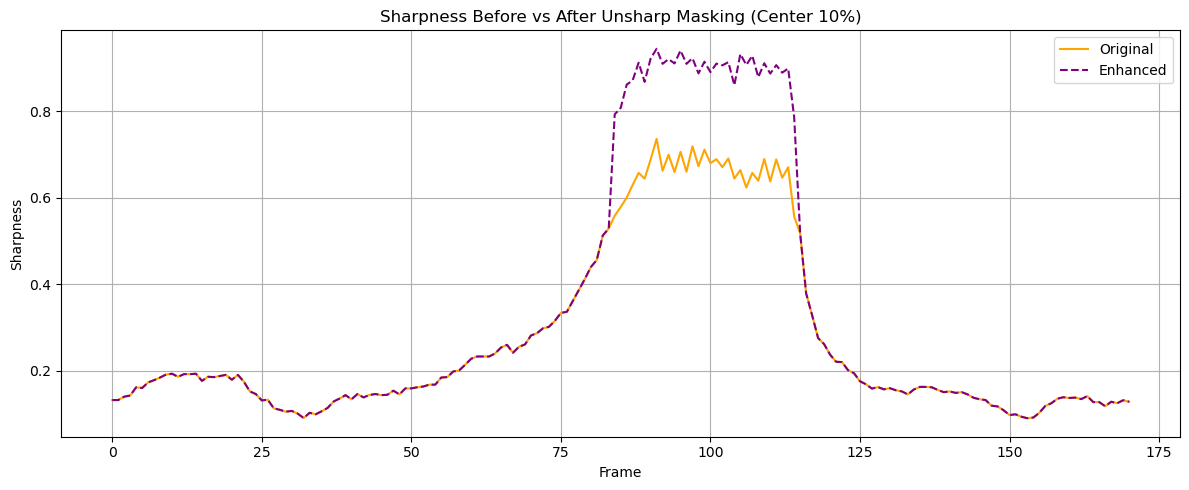

In [40]:
# Aplicar mejora en el frame entero
enhanced_full = enhance_and_compare(
    original_frames=frames,
    sharpness_fn=sharpness_FM,
    region_selector="full",
    sharpness_values=fm_full,
    threshold_high=1.0
)
plot_comparison(fm_full, enhanced_full, region_label="Full Frame")

# Aplicar mejora en la región central
enhanced_center = enhance_and_compare(
    original_frames=frames,
    sharpness_fn=sharpness_FM,
    region_selector="center",
    sharpness_values=fm_center,
    threshold_high=1.0
)
plot_comparison(fm_center, enhanced_center, region_label="Center 10%")